In [1]:
import os
import random
import shutil
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

In [2]:
# Paths
PROJECT_ROOT = Path.cwd().resolve().parents[0]
DATA_ROOT = PROJECT_ROOT / "data" / "modern_dataset"

TRAIN_DIR = DATA_ROOT / "Train"
VAL_DIR = DATA_ROOT / "Validation"
TEST_DIR = DATA_ROOT / "Test"

IMAGE_SIZE = (224, 224)
BATCH_SIZE = 32
SEED = 42

print("PROJECT_ROOT:", PROJECT_ROOT)
print("DATA_ROOT:", DATA_ROOT)
print("Train exists:", TRAIN_DIR.exists())
print("Validation exists:", VAL_DIR.exists())
print("Test exists:", TEST_DIR.exists())

PROJECT_ROOT: C:\Users\zakiz\Downloads\COMP-487-Project-1-main
DATA_ROOT: C:\Users\zakiz\Downloads\COMP-487-Project-1-main\data\modern_dataset
Train exists: True
Validation exists: True
Test exists: True


In [3]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    seed=SEED
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    VAL_DIR,
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    seed=SEED
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    TEST_DIR,
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

Found 10923 files belonging to 2 classes.
Found 2341 files belonging to 2 classes.
Found 2635 files belonging to 2 classes.


In [4]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)
test_ds = test_ds.cache().prefetch(buffer_size=AUTOTUNE)

In [5]:
data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
])

base_model = tf.keras.applications.EfficientNetB0(
    include_top=False,
    weights="imagenet",
    input_shape=(224, 224, 3)
)

base_model.trainable = False

inputs = keras.Input(shape=(224, 224, 3))
x = data_augmentation(inputs)
x = tf.keras.applications.efficientnet.preprocess_input(x)
x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.3)(x)
outputs = layers.Dense(1, activation="sigmoid")(x)

model = keras.Model(inputs, outputs)

In [6]:
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

In [7]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=5
)

Epoch 1/5
342/342 ━━━━━━━━━━━━━━━━━━━━ 179s 410ms/step - accuracy: 0.9326 - loss: 0.1994 - val_accuracy: 0.9722 - val_loss: 0.0954
Epoch 2/5
342/342 ━━━━━━━━━━━━━━━━━━━━ 133s 390ms/step - accuracy: 0.9718 - loss: 0.0903 - val_accuracy: 0.9791 - val_loss: 0.0715
Epoch 3/5
342/342 ━━━━━━━━━━━━━━━━━━━━ 135s 394ms/step - accuracy: 0.9756 - loss: 0.0744 - val_accuracy: 0.9821 - val_loss: 0.0605
Epoch 4/5
342/342 ━━━━━━━━━━━━━━━━━━━━ 152s 446ms/step - accuracy: 0.9765 - loss: 0.0659 - val_accuracy: 0.9833 - val_loss: 0.0546
Epoch 5/5
342/342 ━━━━━━━━━━━━━━━━━━━━ 138s 404ms/step - accuracy: 0.9785 - loss: 0.0638 - val_accuracy: 0.9842 - val_loss: 0.0479


In [8]:
test_loss, test_acc = model.evaluate(test_ds)
print("Test accuracy:", test_acc)

83/83 ━━━━━━━━━━━━━━━━━━━━ 30s 356ms/step - accuracy: 0.9806 - loss: 0.0586
Test accuracy: 0.9806451797485352


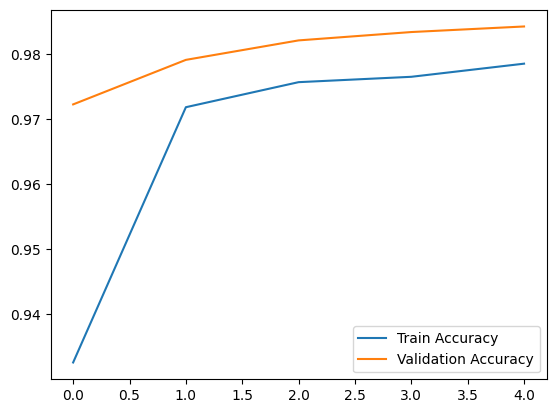

In [9]:
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.legend()
plt.show()